In [1]:
import numpy as np
import matplotlib.pyplot as plt

image_i = np.array([
    [0, 1, 1, 2],
    [2, 3, 3, 4],
    [4, 5, 6, 6],
    [5, 6, 7, 7]
])

Compute Histogram Result: [1 2 2 2 2 2 3 2]


<function matplotlib.pyplot.show(close=None, block=None)>

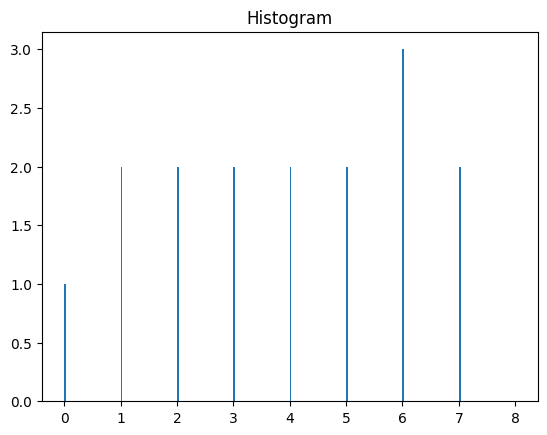

In [3]:
#Compute histogram
def histogram():
    #8: Grey range 0 -> 7
    histo = [0] * 8
    #Count intensity of each pixel
    for row in image_i:
        for pixel in row:
            histo[pixel] += 1
    return np.array(histo)

a = histogram()
print(f"Compute Histogram Result: {a}")

#Plot histogram
plt.title("Histogram")
plt.hist(image_i.ravel(), bins=256, range=[0, 8])
plt.show

Compute Normalized Histogram: [0.0625 0.125  0.125  0.125  0.125  0.125  0.1875 0.125 ]


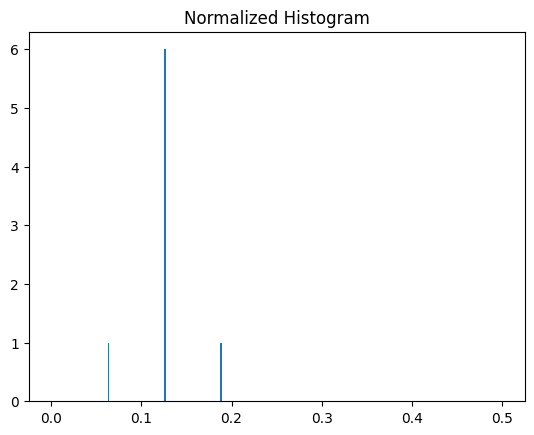

In [4]:
#Compute normalized histogram
def normalized_histogram():
    #Formula: Divide each intensity value to total number of pixels
    h = histogram()
    return h/image_i.size

b = normalized_histogram()
print(f"Compute Normalized Histogram: {b}")

#Plot normalized histogram
plt.title("Normalized Histogram")
plt.hist(b.ravel(), bins = 256, range=[0, 0.5])
plt.show()

Compute Equalized Histogram: [1, 2, 2, 2, 2, 2, 3, 2]


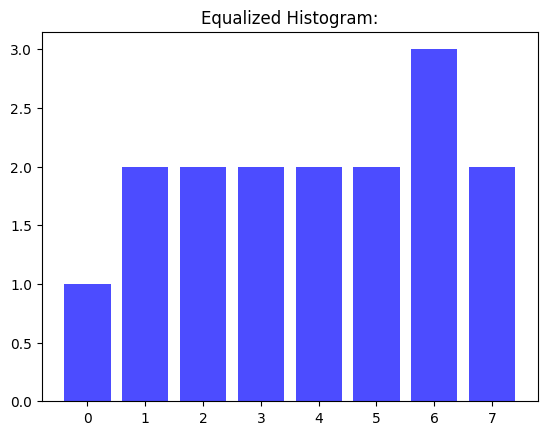

New image M: 
[[0 1 1 2]
 [2 3 3 4]
 [4 5 6 6]
 [5 6 7 7]]


In [16]:
#Compute Equalized Histogram
def equalized_histogram():
    cdf = np.cumsum(b)
    #7: The highest grey level 
    mapping = np.round(7 * cdf).astype(int)
    equalized_histo = [0] * 8
    for r in range(8):
        s = mapping[r]
        equalized_histo[s] += a[r]
        
    return mapping, equalized_histo

mapping_table, histo_m = equalized_histogram()

print(f"Compute Equalized Histogram: {histo_m}")

#Plot equalized histogram
plt.bar(range(8), histo_m, color='blue', alpha=0.7)
plt.title("Equalized Histogram:")
plt.show()

#Infer new image M
def infer_image_m(original_image, mapping):
    new_image = np.zeros_like(original_image)
    for r in range(original_image.shape[0]):
        for c in range(original_image.shape[1]):
            new_image[r, c] = mapping[original_image[r, c]]
    return new_image

m = infer_image_m(image_i, mapping_table)
print(f"New image M: \n{m}")

In [17]:
import numpy as np

def convert_to_binary(image_i):
    #Find the middle value of all pixels in image I
    k = np.median(image_i)
    #uint8: Convert True, False to 1,0
    binary_image_b = (image_i >= k).astype(np.uint8)
    
    return binary_image_b, k

binary_image_b, k_threshold = convert_to_binary(image_i)

print(f"Threshold k: {k_threshold}")
print(f"Image B: \n{binary_image_b}")

Threshold k: 4.0
Image B: 
[[0 0 0 0]
 [0 0 0 1]
 [1 1 1 1]
 [1 1 1 1]]


In [15]:
def compute_negative(og_image):
    #Highest pixel - each pixel
    negative_i = 7 - og_image
    return negative_i
neg_i = compute_negative(image_i)
print(f"Compute negative of image I: \n{neg_i}")

Compute negative of image I: 
[[7 6 6 5]
 [5 4 4 3]
 [3 2 1 1]
 [2 1 0 0]]
